In [ ]:
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
scores = [85, 90, 78, 92, 85, 88, 76, 95, 85, 100]

# 평균, 중앙값, 최빈값
mean = np.mean(scores)
median = np.median(scores)
mode = stats.mode(scores, keepdims=True)

print(f"평균: {mean}")
print(f"중앙값: {median}")
print(f"최빈값: {mode}")

평균: 87.4
중앙값: 86.5
최빈값: ModeResult(mode=array([85]), count=array([3]))


In [ ]:
class_A = [85, 87, 86, 88, 84, 86, 85, 87, 86, 85]
class_B = [95, 75, 90, 70, 85, 95, 65, 90, 75, 80]

# A반
mean_A = np.mean(class_A)
var_A = np.var(class_A, ddof=1) # 표본분산
std_A = np.std(class_A, ddof=1) # 표본표준편차

# B반
mean_B = np.mean(class_B)
var_B = np.var(class_B, ddof=1) # 표본분산
std_B = np.std(class_B, ddof=1) # 표본표준편차

print(f"A반 - 평균: {mean_A:.2f}, 분산: {var_A:.2f}, 표준편차: {std_A:.2f}")
print(f"B반 - 평균: {mean_B:.2f}, 분산: {var_B:.2f}, 표준편차: {std_B:.2f}")

A반 - 평균: 85.90, 분산: 1.43, 표준편차: 1.20
B반 - 평균: 82.00, 분산: 112.22, 표준편차: 10.59


In [ ]:
# 주사위 1000번 던지기 시뮬레이션 -> 임시 데이터 만들기
np.random.seed(42)
dice_rolls = np.random.randint(1, 7, size=1000)

# 각 눈의 출현 빈도
unique, counts = np.unique(dice_rolls, return_counts=True)
probabilities = counts / len(dice_rolls)

print("주사위 눈금별 확률")
for num, prob in zip(unique, probabilities):
  print(f"{num}: {prob:.3f} (이론값: {1/6:.3f})")

주사위 눈금별 확률
1: 0.181 (이론값: 0.167)
2: 0.164 (이론값: 0.167)
3: 0.154 (이론값: 0.167)
4: 0.174 (이론값: 0.167)
5: 0.172 (이론값: 0.167)
6: 0.155 (이론값: 0.167)


In [ ]:
# 확률변수 X: 주사위 두 개를 던져 나온 합
dice1 = np.random.randint(1, 7, size=1000)
dice2 = np.random.randint(1, 7, size=1000)
X = dice1 + dice2 # 확률변수 X

# 확률분포표
unique_sums, counts_sums = np.unique(X, return_counts=True)
prob_dist = counts_sums / len(X)

print("두 주사위 합의 확률분포")
for sum_val, prob in zip(unique_sums, prob_dist):
  print(f"X={sum_val}: {prob:.3f}")

# 기댓값
E_x = np.sum(unique_sums * prob_dist)
print(f"기댓값: {E_x}")

# 분산
Var_x = np.sum((unique_sums - E_x)**2 * prob_dist)
print(f"분산: {Var_x}")


두 주사위 합의 확률분포
X=2: 0.035
X=3: 0.051
X=4: 0.087
X=5: 0.111
X=6: 0.145
X=7: 0.174
X=8: 0.129
X=9: 0.106
X=10: 0.069
X=11: 0.065
X=12: 0.028
기댓값: 6.941000000000001
분산: 5.9735190000000005


In [ ]:
from scipy.stats import norm, binom, poisson

# 1. 정규분포
mu = 0
sigma = 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
pdf_normal = norm.pdf(x, loc=mu, scale=sigma) # -> 정규분포 생성

# 2. 이항분포
n = 10
p = 0.5
k_binom = np.arange(0, n+1)
pmf_binomial = binom.pmf(k_binom, n, p) # -> 이항분포 생성

# 3. 푸아송분포
lambda_poisson = 3
k_poisson = np.arange(0, 10)
pmf_poisson = poisson.pmf(k_poisson, lambda_poisson) # -> 푸아송분포 생성

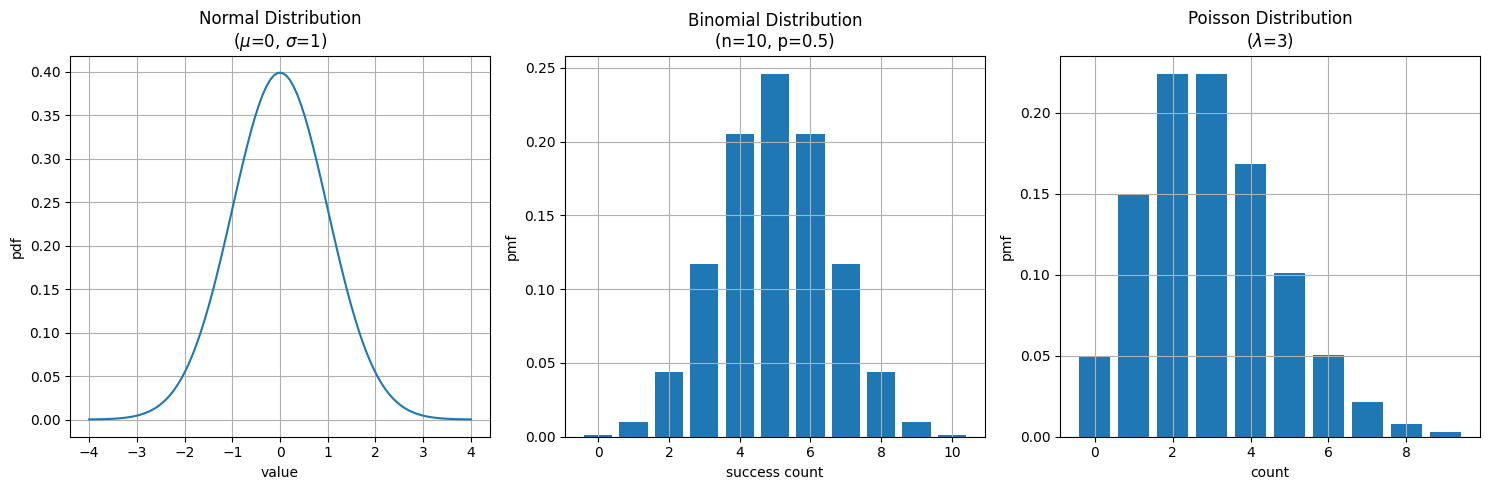

In [ ]:
from scipy.stats import norm, binom, poisson
import matplotlib.pyplot as plt

# 1. 정규 분포 (Normal Distribution)
# 평균(mu)과 표준편차(sigma)를 사용하여 분포 정의
mu = 0
sigma = 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
pdf_normal = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(x, pdf_normal)
plt.title(f'Normal Distribution\n($\mu$={mu}, $\sigma$={sigma})')
plt.xlabel('value')
plt.ylabel('pdf')
plt.grid(True)

# 2. 이항 분포 (Binomial Distribution)
# 시행 횟수(n)와 성공 확률(p)을 사용하여 분포 정의
n = 10 # 10번의 독립 시행
p = 0.5 # 각 시행의 성공 확률
k_binom = np.arange(0, n + 1)
pmf_binomial = binom.pmf(k_binom, n, p)

plt.subplot(1, 3, 2)
plt.bar(k_binom, pmf_binomial)
plt.title(f'Binomial Distribution\n(n={n}, p={p})')
plt.xlabel('success count')
plt.ylabel('pmf')
plt.grid(True)

# 3. 푸아송 분포 (Poisson Distribution)
# 단위 시간/공간당 평균 발생 횟수($\lambda$)를 사용하여 분포 정의
lambda_poisson = 3 # 평균 발생 횟수
k_poisson = np.arange(0, 10)
pmf_poisson = poisson.pmf(k_poisson, lambda_poisson)

plt.subplot(1, 3, 3)
plt.bar(k_poisson, pmf_poisson)
plt.title(f'Poisson Distribution\n($\lambda$={lambda_poisson})')
plt.xlabel('count')
plt.ylabel('pmf')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 샘플데이터 생성
np.random.seed(42)
data = np.random.normal(loc=50, scale=10, size=100)

# 모집단 평균의 점추정
point_estimation_mean = np.mean(data)
print(f"모집단 평균의 점추정: {point_estimation_mean:.2f}")

# 모집단 표준편차의 점추정
point_estimation_std = np.std(data, ddof=1)
print(f"모집단 표준편차의 점추정: {point_estimation_std:.2f}")


모집단 평균의 점추정: 48.96
모집단 표준편차의 점추정: 9.08


In [ ]:
# 실습 시나리오: 한 학교 학생 100명의 키를 측정
np.random.seed(42)
heights = np.random.normal(loc=170, scale=8, size=100) # 실제 키 평균 170cm

sample_mean = np.mean(heights)
sample_std = np.std(heights, ddof=1)
sample_size = len(heights)

print(f"측정한 학생 수: {sample_size}명")
print(f"측정된 평균 키: {sample_mean:.2f}cm")

측정한 학생 수: 100명
측정된 평균 키: 169.17cm


In [ ]:
# 95% 신뢰구간 계산
confidence_level = 0.95
se = sample_std / np.sqrt(sample_size)
df_freedom = sample_size - 1
t_critical = stats.t.ppf(0.975, df_freedom) # 양쪽 2.5% 씩
margin_of_error = t_critical * se

lower = sample_mean - margin_of_error
upper = sample_mean + margin_of_error

print(f"\n[구간추정 결과]")
print(f"전체 학생의 평균 키는")
print(f"{lower:.2f}cm ~ {upper:.2f}cm 입니다 (95% 신뢰)")
print(f"\n해석: 이 학교 전체 학생의 실제 평균 키가")
print(f"     이 구간 안에 있을 가능성이 95%입니다.")


[구간추정 결과]
전체 학생의 평균 키는
167.73cm ~ 170.61cm 입니다 (95% 신뢰)

해석: 이 학교 전체 학생의 실제 평균 키가
     이 구간 안에 있을 가능성이 95%입니다.


In [ ]:
# 다른 신뢰수준과 비교
for conf in [0.90, 0.95, 0.99]:
  t_val = stats.t.ppf((1 + conf)/2, df_freedom)
  me = t_val * se
  print(f"{conf*100:.0f}% 신뢰구간: [{sample_mean - me:.2f}, {sample_mean + me:.2f}]cm")
  print(f"  -> 구간 폭: {2*me:.2f}cm")

90% 신뢰구간: [167.96, 170.38]cm
  -> 구간 폭: 2.41cm
95% 신뢰구간: [167.73, 170.61]cm
  -> 구간 폭: 2.88cm
99% 신뢰구간: [167.26, 171.08]cm
  -> 구간 폭: 3.82cm


In [ ]:
# 실습 시나리오: 과자 회사에서 "평균 무게 100g"이라고 광고
# 실제 100g인지 검증
np.random.seed(42)
weights = np.random.normal(loc=98, scale=5, size=100)

print("가설검정 실습: 과자 무게가 광고대로 100g인가?")

sample_mean = np.mean(weights)
sample_std = np.std(weights)
sample_size = len(weights)

print(f"\n[측정 결과]")
print(f"측정한 과자 개수: {sample_size}개")
print(f"측정된 평균 무게: {sample_mean:.2f}g")
print(f"측정된 표준편차: {sample_std:.2f}g")

가설검정 실습: 과자 무게가 광고대로 100g인가?

[측정 결과]
측정한 과자 개수: 100개
측정된 평균 무게: 97.48g
측정된 표준편차: 4.52g


In [ ]:
# 가설설정
# 귀무가설 H0: 과자의 실제 평균은 100g이다
# 대립가설 H1: 과자의 실제 평균은 100g이 아니다

h_mean = 100
alpha = 0.05

t_statistic, p_value = stats.ttest_1samp(weights, h_mean)
# 단일 표본 t-검정 -> 평균에 대한 가설검정에 사용하는 방법

print(f"t-통계량: {t_statistic:.4f}")
print(f"p-값: {p_value:.4f}")

t-통계량: -5.5479
p-값: 0.0000


In [ ]:
# 결과 해석
if p_value < alpha:
    print(f"p-값({p_value:.4f}) < 유의수준({alpha})")
    print(f"\t→ 귀무가설을 기각합니다.")
    print(f"\n[결론]")
    print(f"\t과자의 실제 평균 무게는 광고한 {h_mean}g과")
    print(f"\t통계적으로 유의미하게 다릅니다.")
    print(f"\t(측정 평균: {sample_mean:.2f}g)")
    print(f"\n\t→ 광고와 실제가 다르다는 증거가 충분합니다!")
else:
    print(f"p-값({p_value:.4f}) ≥ 유의수준({alpha})")
    print(f"\t→ 귀무가설을 기각할 수 없습니다.")
    print(f"\n[결론]")
    print(f"\t과자의 실제 평균 무게가 {h_mean}g과 다르다는")
    print(f"\t충분한 증거가 없습니다.")
    print(f"\n\t→ 광고대로 {h_mean}g이라고 볼 수 있습니다.")

p-값(0.0000) < 유의수준(0.05)
	→ 귀무가설을 기각합니다.

[결론]
	과자의 실제 평균 무게는 광고한 100g과
	통계적으로 유의미하게 다릅니다.
	(측정 평균: 97.48g)

	→ 광고와 실제가 다르다는 증거가 충분합니다!
